In [1]:
import scipy.stats as stats
import os
import glob
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq


shRNAoneDir = '/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/miR_shRNAone'
Libdirectory = '/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/miR_screening_ref.txt'



Dfiles = [f for f in os.listdir(shRNAoneDir) if f.endswith('sorted.txt')]
Dfiles.sort()
print(Dfiles)

for file in Dfiles:
    file_path = os.path.join(shRNAoneDir, file)
    data = pd.read_csv(file_path, delimiter='\t', names=['Count', 'complementary_seq'])
    if "SF015" in file:
        variable_name = 'rep1_day' + file[7:].split("_L1_2")[0].replace("-", "_")
    else:
        variable_name = 'rep' + file[8:9] + "_day" + file[11:].split("_L")[0]
    globals()[variable_name] = data
    print(file, variable_name)


sequence_name = []
sequence = []

df_ref = pd.read_table("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/miR_screening_ref.txt", sep="\t")
df_ref['guide_seq'] = [str(Seq(x).reverse_complement()) for x in df_ref['complementary_seq']]
df_ref["type"] = [x.split("|")[0] for x in df_ref["name"]]
df_ref["miRNA"] = [x.split("|")[1] for x in df_ref["name"]]


df_shRNAone = df_ref.merge(rep1_day00, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep1_day00"})

df_shRNAone = df_shRNAone.merge(rep1_day05, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep1_day05"})

df_shRNAone = df_shRNAone.merge(rep1_day12_DMSO, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep1_day12_DMSO"})

df_shRNAone = df_shRNAone.merge(rep1_day12_Sorafenib, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep1_day12_Sorafenib"})

df_shRNAone = df_shRNAone.merge(rep2_day00, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep2_day00"})

df_shRNAone = df_shRNAone.merge(rep2_day05, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep2_day05"})

df_shRNAone = df_shRNAone.merge(rep2_day12_DMSO, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep2_day12_DMSO"})

df_shRNAone = df_shRNAone.merge(rep2_day12_Sorafenib, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep2_day12_Sorafenib"})

df_shRNAone = df_shRNAone.merge(rep3_day00, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep3_day00"})

df_shRNAone = df_shRNAone.merge(rep3_day05, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep3_day05"})

df_shRNAone = df_shRNAone.merge(rep3_day12_DMSO, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep3_day12_DMSO"})

df_shRNAone = df_shRNAone.merge(rep3_day12_Sorafenib, how='left')
df_shRNAone = df_shRNAone.rename(columns={"Count": "rep3_day12_Sorafenib"})

df_shRNAone = df_shRNAone.drop(columns=['complementary_seq'])

columns_range = df_shRNAone.columns[4:]
column_sums = df_shRNAone[columns_range].sum()

for column in range(len(columns_range)):
    df_shRNAone[columns_range[column] + "_CPM"] = df_shRNAone[columns_range[column]] / column_sums.iloc[column] * 1000000

df_shRNAone["rep1_Log2FC"] = [np.log2((df_shRNAone["rep1_day12_DMSO"][x]) / (df_shRNAone["rep1_day12_Sorafenib"][x])) if (df_shRNAone["rep1_day12_DMSO"][x] > 50 and df_shRNAone["rep1_day12_Sorafenib"][x] > 50) else np.nan for x in range(len(df_shRNAone))]
df_shRNAone["rep2_Log2FC"] = [np.log2((df_shRNAone["rep2_day12_DMSO"][x]) / (df_shRNAone["rep2_day12_Sorafenib"][x])) if (df_shRNAone["rep2_day12_DMSO"][x] > 50 and df_shRNAone["rep2_day12_Sorafenib"][x] > 50) else np.nan for x in range(len(df_shRNAone))]
df_shRNAone["rep3_Log2FC"] = [np.log2((df_shRNAone["rep3_day12_DMSO"][x]) / (df_shRNAone["rep3_day12_Sorafenib"][x])) if (df_shRNAone["rep3_day12_DMSO"][x] > 50 and df_shRNAone["rep3_day12_Sorafenib"][x] > 50) else np.nan for x in range(len(df_shRNAone))]

numeric_cols = ['rep1_Log2FC', 'rep2_Log2FC', 'rep3_Log2FC']
df_shRNAone["Log2FC_mean"] = df_shRNAone[numeric_cols].mean(axis=1)
df_shRNAone["Log2FC_std"] = df_shRNAone[numeric_cols].std(axis=1)

df_shRNAone.to_csv("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/Log2FC_miR_shRNAone_biological_replicates.csv", index=False)
# matrix_DESeq2 = df_shRNAone[["name", "rep1_day00", "rep1_day05", "rep1_day12_DMSO", "rep1_day12_Sorafenib",
#                            "rep2_day00", "rep2_day05", "rep2_day12_DMSO", "rep2_day12_Sorafenib",
#                            "rep3_day00", "rep3_day05", "rep3_day12_DMSO", "rep3_day12_Sorafenib"]]
# matrix_DESeq2.to_csv("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/DESeq2_input/shRNAone_miR_matrix.csv", index = False)

['SF015-D00_L1_2.filtered_and_sorted.txt', 'SF015-D05_L1_2.filtered_and_sorted.txt', 'SF015-D12-DMSO_L1_2.filtered_and_sorted.txt', 'SF015-D12-Sorafenib_L1_2.filtered_and_sorted.txt', 'SF017_br2_D00_L1_2.filtered_and_sorted.txt', 'SF017_br2_D05_L1_2.filtered_and_sorted.txt', 'SF017_br2_D12_DMSO_L1_2.filtered_and_sorted.txt', 'SF017_br2_D12_Sorafenib_L1_2.filtered_and_sorted.txt', 'SF017_br3_D00_L1_2.filtered_and_sorted.txt', 'SF017_br3_D05_L1_2.filtered_and_sorted.txt', 'SF017_br3_D12_DMSO_L1_2.filtered_and_sorted.txt', 'SF017_br3_D12_Sorafenib_L1_2.filtered_and_sorted.txt']
SF015-D00_L1_2.filtered_and_sorted.txt rep1_day00
SF015-D05_L1_2.filtered_and_sorted.txt rep1_day05
SF015-D12-DMSO_L1_2.filtered_and_sorted.txt rep1_day12_DMSO
SF015-D12-Sorafenib_L1_2.filtered_and_sorted.txt rep1_day12_Sorafenib
SF017_br2_D00_L1_2.filtered_and_sorted.txt rep2_day00
SF017_br2_D05_L1_2.filtered_and_sorted.txt rep2_day05
SF017_br2_D12_DMSO_L1_2.filtered_and_sorted.txt rep2_day12_DMSO
SF017_br2_D12_So

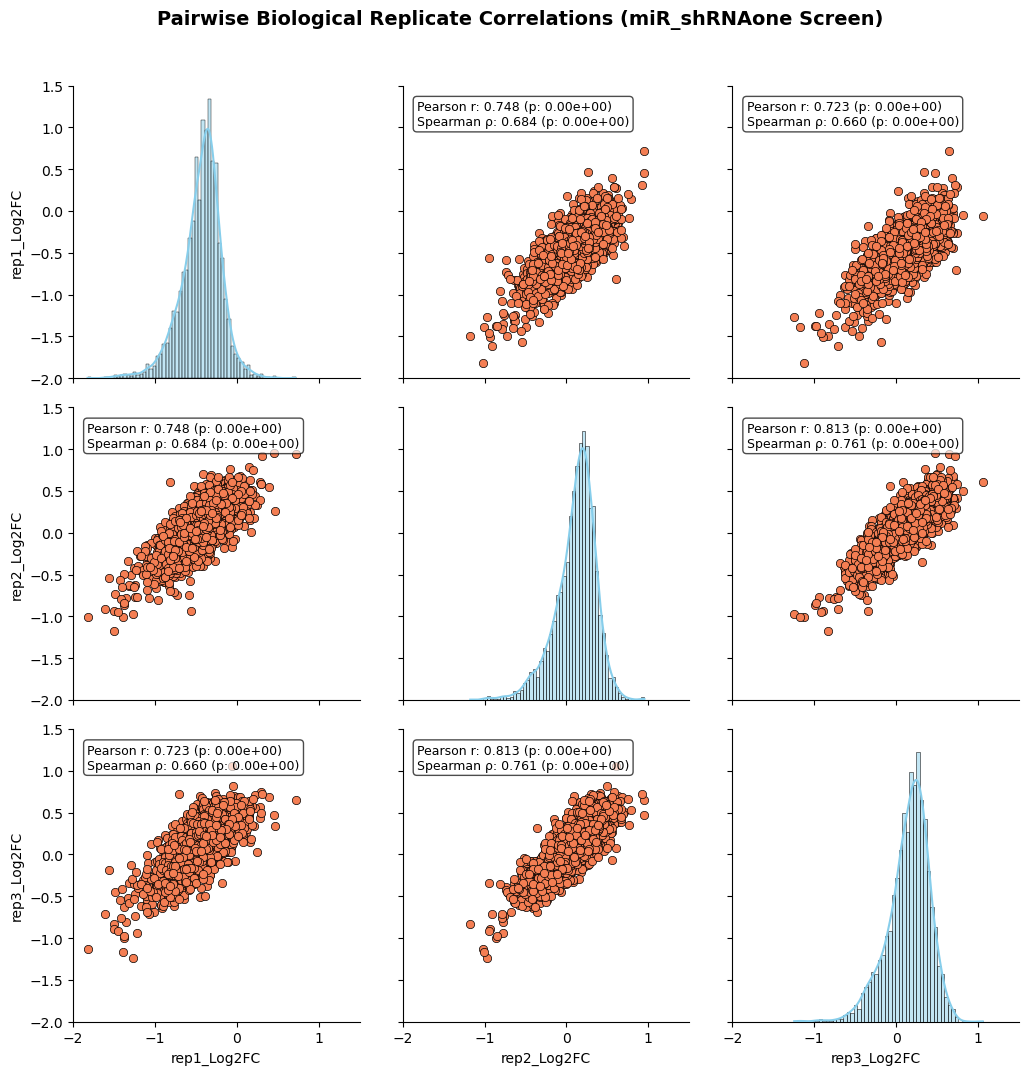

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr


screen = ["miR_shRNAone"]
dataDir = ["/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/Log2FC_miR_shRNAone_biological_replicates.csv"]

for screen, data in zip(screen, dataDir):
    df_screen = pd.read_csv(data)
    columns = [x for x in df_screen.columns.tolist() if x.endswith("Log2FC")]
    df_screen = df_screen[columns]
    df_screen

    #######################################################################################################################
    #######################################################################################################################
    #######################################################################################################################
    def annotate_stats(x, y, **kwargs):
        # Drop NaNs dynamically for calculating correlations if any rows are missing data
        mask = x.notna() & y.notna()
        x_clean, y_clean = x[mask], y[mask]

        if len(x_clean) < 2:
            return  # Not enough data points to compute correlation

        # Calculate Pearson and Spearman stats
        p_coef, p_val = pearsonr(x_clean, y_clean)
        s_coef, s_val = spearmanr(x_clean, y_clean)

        # Format text labels (scientific notation for p-values is safest for small numbers)
        stats_text = (
            f"Pearson r: {p_coef:.3f} (p: {p_val:.2e})\n"
            f"Spearman ρ: {s_coef:.3f} (p: {s_val:.2e})"
        )

        # Grab current axes object
        ax = plt.gca()

        # Place text box in the upper-left or lower-right corner depending on preference
        ax.text(
            0.05,
            0.95,
            stats_text,
            transform=ax.transAxes,
            verticalalignment="top",
            horizontalalignment="left",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
        )


    # 3. Initialize the PairGrid object
    # We use 'vars' to strictly limit the plotting to your 3 target replicate columns
    g = sns.PairGrid(df_screen, vars=columns, height=3.5)

    # 4. Map plots to the Grid
    # Diagonal: Distribution histograms
    g.map_diag(sns.histplot, kde=True, color="skyblue")

    # Off-diagonal (upper and lower triangles): Scatter plots
    g.map_offdiag(sns.scatterplot, alpha=1, color="#f47e53", edgecolor="#000000", linewidth = 0.5)

    # 5. Map the annotation function to the off-diagonal plots
    g.map_offdiag(annotate_stats)

    g.set(xlim=(-2, 1.5), ylim=(-2, 1.5))

    # 6. Aesthetic adjustment & show
    plt.suptitle(
        "Pairwise Biological Replicate Correlations (" + screen + " Screen)",
        y=1.02,
        fontsize=14,
        weight="bold",
    )
    plt.tight_layout()
    plt.savefig("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_figure/figures/preprocessing/correlations_" + screen + ".pdf", bbox_inches="tight")
    plt.show()

In [7]:
# Load the data
df = pd.read_excel("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/Log2FC_miR_shRNAone_DESeq2.xlsx")

# Filter significant results for each category (padj < 0.05)
filters = {
    "miR1A":     df["type"] == "miR1A",
    "miR1U":     df["type"] == "miR1U",
    "miR_7merSupp": df["type"] == "miR_7merSupp",
    "miR_7mer":  df["type"] == "miR_7mer",
    "miR_6mer":  df["type"] == "miR_6mer",
}

sig = {
    name: df[cond & (df["padj"] < 0.05)].copy()
    for name, cond in filters.items()
}

# Find miRNAs that are significant in ALL categories
common_miRNAs = set.intersection(
    *(set(df_cat["miRNA"]) for df_cat in sig.values())
)

# Keep only common miRNAs and sort consistently
for name in sig:
    sig[name] = (
        sig[name][sig[name]["miRNA"].isin(common_miRNAs)]
        .sort_values("miRNA")
        .reset_index(drop=True)
    )

# Create the comparison dataframe using the aligned data
df_common = pd.DataFrame({
    "miRNA": sig["miR1A"]["miRNA"]
})

# Calculate deltas (U as reference)
df_common["delta_log2FC_AvsU"]  = sig["miR1U"]["log2FoldChange"] - sig["miR1A"]["log2FoldChange"]
df_common["delta_log2FC_Uv7s"]  = sig["miR1U"]["log2FoldChange"] - sig["miR_7merSupp"]["log2FoldChange"]
df_common["delta_log2FC_Uv7"]   = sig["miR1U"]["log2FoldChange"] - sig["miR_7mer"]["log2FoldChange"]
df_common["delta_log2FC_Uv6"]   = sig["miR1U"]["log2FoldChange"] - sig["miR_6mer"]["log2FoldChange"]

# Final filtering
df_common = df_common[
    (df_common["delta_log2FC_AvsU"] < 0.1) & 
    (df_common["delta_log2FC_Uv7s"] > 0.2)
].reset_index(drop=True)
df_common
# Optional: sort by a delta of interest
# df_common = df_common.sort_values("delta_log2FC_Uv7s", ascending=False)

,miRNA,delta_log2FC_AvsU,delta_log2FC_Uv7s,delta_log2FC_Uv7,delta_log2FC_Uv6
0,Hsa-Mir-155_5p,0.031663,0.458147,0.588692,0.319892


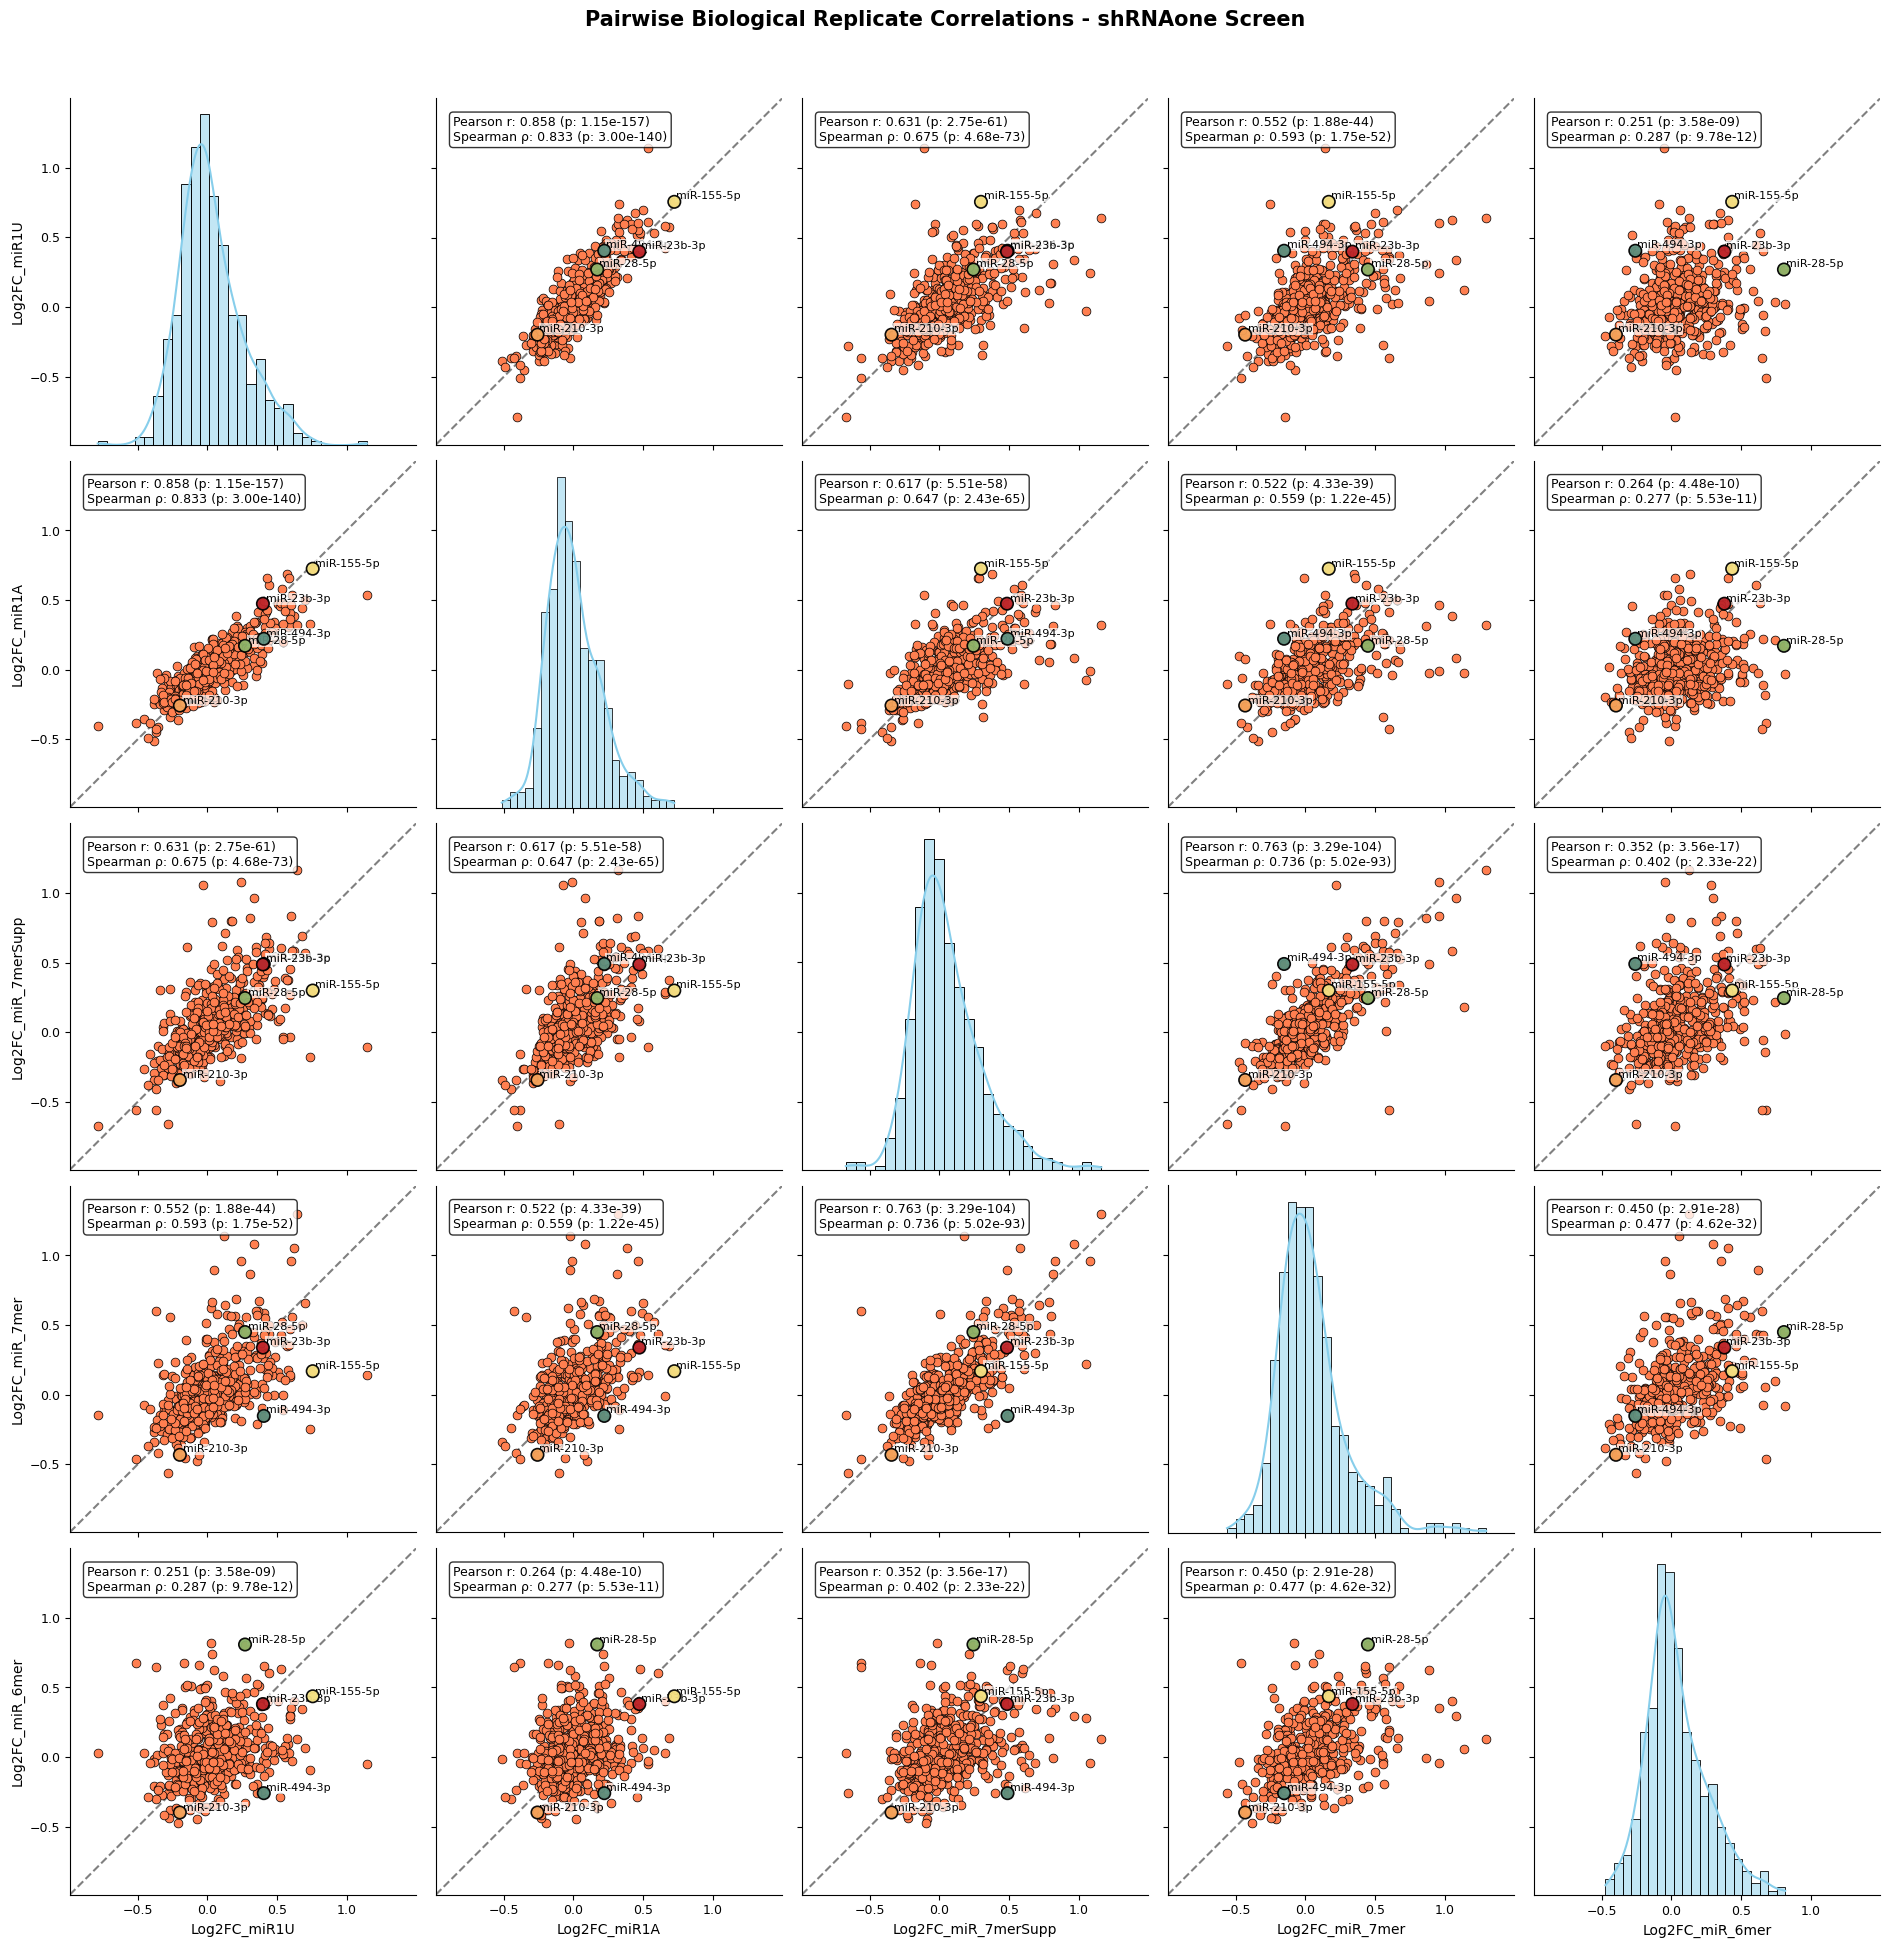

In [6]:
"""
Pairwise biological-replicate correlation plots for miRNA screen Log2FC data.

For each screen, this loads an Excel file of Log2FC columns, builds a
seaborn PairGrid (scatter off-diagonal, histogram on the diagonal), overlays
Pearson/Spearman stats on each scatter panel, and optionally highlights a
set of named miRNAs.
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np

# ====================== CONFIGURATION ======================
ID_COL = "miRNA"  # column in the source Excel file that identifies each row

# Example usage - customize these per screen or globally
# highlight_names = ["Hsa-Mir-483_5p", "Hsa-Mir-493_5p", "Hsa-Mir-9-P1_3p", "Hsa-Mir-28-P3_5p", 
#                    "Hsa-Mir-770_5p", "Hsa-Mir-430-P47_5p", "Hsa-Mir-541_3p", 
#                    "Hsa-Mir-542-v1_3p", "Hsa-Mir-452-v1_5p", "Hsa-Mir-335_3p", "Hsa-Mir-154_P18_3p"]

highlight_names = ["Hsa-Mir-23-P2_3p", "Hsa-Mir-28-P1_5p", "Hsa-Mir-155_5p", "Hsa-Mir-210_3p", "Hsa-Mir-154-P18_3p"]

highlight_colors = ["#bc2429", "#8cb368", "#f4e182", "#f4a259", "#5b8e7d"]#, "#3a86ff", "#ff6fb0", "#00b4d8", "#adb5bd", "#bde0fe", "#000000"]  # one color per name, or a single color for all

# label_names = ["miR-483-5p", "miR-493-5p", "miR-9-3p", "miR-708-5p", 
#                "miR-770-5p", "miR-526b-5p", "miR-541-3p", 
#                "miR-542-3p", "miR-452-5p", "miR-335-3p", "miR-494-3p"]
label_names = ["miR-23b-3p", "miR-28-5p", "miR-155-5p", "miR-210-3p", "miR-494-3p"]

# Optional: size and style of highlighted points
highlight_size = 80
highlight_alpha = 0.95
highlight_edgecolor = "black"
highlight_linewidth = 1.2

dataDirs = ["/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/Log2FC_miR_shRNAone_byType.xlsx"]
screens = ["shRNAone"]
# ===========================================================

if len(highlight_colors) > 1 and len(highlight_colors) != len(highlight_names):
    raise ValueError("highlight_colors must have length 1 or match highlight_names")

if label_names is not None and len(label_names) != len(highlight_names):
    raise ValueError("label_names must be None or match the length of highlight_names")


def annotate_stats(x, y, **kwargs):
    """Add Pearson/Spearman correlation stats as text in the top-left of the axis."""
    mask = x.notna() & y.notna()
    x_clean, y_clean = x[mask], y[mask]
    if len(x_clean) < 2:
        return

    p_coef, p_val = pearsonr(x_clean, y_clean)
    s_coef, s_val = spearmanr(x_clean, y_clean)

    stats_text = (
        f"Pearson r: {p_coef:.3f} (p: {p_val:.2e})\n"
        f"Spearman ρ: {s_coef:.3f} (p: {s_val:.2e})"
    )
    ax = plt.gca()
    ax.text(
        0.05, 0.95, stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )


def scatter_with_highlight(x, y, highlight_df, highlight_names, highlight_colors,
                            label_names=None, id_col=ID_COL, **kwargs):
    """Scatter plot for a PairGrid off-diagonal panel, with selected points highlighted."""
    ax = plt.gca()

    # PairGrid.map_offdiag injects its own 'color' kwarg into every call; drop it
    # so it doesn't collide with the explicit color="coral" below.
    kwargs.pop("color", None)

    # Background points
    sns.scatterplot(
        x=x, y=y,
        color="coral",
        # alpha=0.5,
        edgecolor="black",
        s=40,
        ax=ax,
        **kwargs
    )

    if not highlight_names:
        return

    mask = highlight_df[id_col].isin(highlight_names)
    highlight_subset = highlight_df[mask]
    if highlight_subset.empty:
        return

    # Resolve a color per highlighted row, preserving highlight_names order
    if len(highlight_colors) == 1:
        colors = [highlight_colors[0]] * len(highlight_subset)
    else:
        color_map = dict(zip(highlight_names, highlight_colors))
        colors = highlight_subset[id_col].map(color_map).tolist()

    # Use matplotlib's scatter directly since it accepts a per-point color list
    ax.scatter(
        highlight_subset[x.name],
        highlight_subset[y.name],
        c=colors,
        s=highlight_size,
        alpha=highlight_alpha,
        edgecolor=highlight_edgecolor,
        linewidth=highlight_linewidth,
        zorder=5,
    )

    # Offset labels relative to the axis range so they scale with the data
    x_range = x.max() - x.min()
    y_range = y.max() - y.min()
    x_off = 0.01 * x_range if x_range else 0
    y_off = 0.01 * y_range if y_range else 0

    # Map each highlighted name to its custom label, falling back to the raw ID
    if label_names:
        label_map = dict(zip(highlight_names, label_names))
    else:
        label_map = {}

    for _, row in highlight_subset.iterrows():
        display_label = label_map.get(row[id_col]) or row[id_col]
        ax.text(
            row[x.name] + x_off, row[y.name] + y_off,
            display_label,
            fontsize=8,
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.5),
        )


def plot_screen_correlations(screen_name, xlsx_path, id_col=ID_COL, save=False):
    """Load one screen's Log2FC data and render its pairwise correlation grid."""
    df_screen = pd.read_excel(xlsx_path)

    log2fc_cols = [c for c in df_screen.columns if c.startswith("Log2FC")]
    if len(log2fc_cols) < 2:
        print(f"Skipping {screen_name}: not enough Log2FC columns")
        return None

    df_screen = df_screen[[id_col] + log2fc_cols].copy()

    g = sns.PairGrid(df_screen, vars=log2fc_cols, height=3.8, diag_sharey=False)
    
    g.set(xlim=(df_screen[log2fc_cols].min().min() - 0.2, df_screen[log2fc_cols].max().max() + 0.2),
          ylim=(df_screen[log2fc_cols].min().min() - 0.2, df_screen[log2fc_cols].max().max() + 0.2))
    
    for ax in g.axes.flat:
        if ax is not None:
            ax.set_box_aspect(1)

    g.map_diag(sns.histplot, kde=True, color="skyblue", edgecolor="black")

    g.map_offdiag(
        scatter_with_highlight,
        highlight_df=df_screen,
        highlight_names=highlight_names,
        highlight_colors=highlight_colors,
        label_names=label_names,
        id_col=id_col,
    )
    for i, j in zip(*np.triu_indices_from(g.axes, k=1)):
        # Upper triangle
        g.axes[i, j].axline((0, 0), slope=1, color='gray', linestyle='--', zorder=0)
        # Lower triangle
        g.axes[j, i].axline((0, 0), slope=1, color='gray', linestyle='--', zorder=0)
    g.map_offdiag(annotate_stats)

    g.figure.suptitle(
        f"Pairwise Biological Replicate Correlations - {screen_name} Screen",
        y=1.02,
        fontsize=15,
        weight="bold",
    )

    for ax in g.axes.flat:
        ax.tick_params(labelsize=9)

    g.figure.tight_layout()

    if save:
        g.figure.savefig(f"correlations_{screen_name}.pdf", bbox_inches="tight", dpi=300)

    return g


if __name__ == "__main__":
    for screen, data_path in zip(screens, dataDirs):
        grid = plot_screen_correlations(screen, data_path, save=True)
        if grid is not None:
            plt.show()

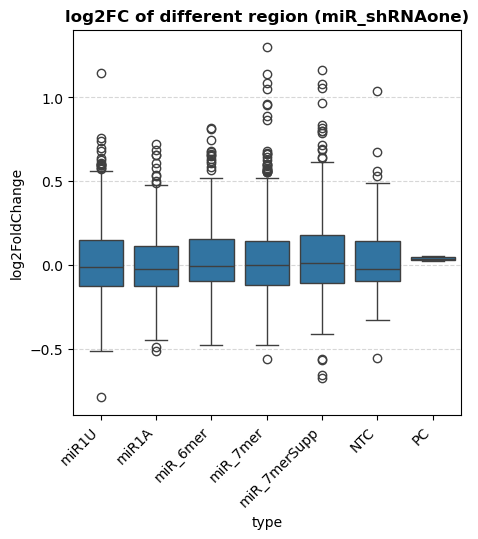

In [17]:
screen = ["miR_shRNAone"]
dataDir = ["/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/Log2FC_miR_shRNAone_DESeq2.xlsx"]

for screen, data in zip(screen, dataDir):
    df = pd.read_excel(data)
    plt.figure(figsize=(5, 5))
    sns.boxplot(x="type", y="log2FoldChange", data=df)
    plt.title("log2FC of different region (" + screen + ")", fontsize=12, weight="bold")
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right")
    plt.savefig("/home/wkkongaa/data/notebooks/260608_tiling_screen_reanalysis/_figure/figures/preprocessing/boxplot_region_" + screen + ".pdf", bbox_inches="tight")
    plt.show()

In [ ]:
import pandas as pd

dataDir = "/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/DESeq2_output/results_shRNAone_miR_DESeq2_output.csv"

df_screen = pd.read_csv(dataDir, header=0, names=["name", "baseMean", "log2FoldChange", "lfcSE", "stat", "pvalue", "padj"])
df_graph = pd.merge(df_shRNAone[["name","guide_seq","type","miRNA"]],df_screen, on="name")

df_graph = df_graph[df_graph["padj"] < 0.05]
counts = df_graph['miRNA'].value_counts()
values_five = counts[counts == 5].index.tolist()
print(values_five)

mirgenedb = ["Hsa-Mir-483_5p", "Hsa-Mir-670_3p", "Hsa-Mir-493_5p", "Hsa-Mir-9-P1_3p", "Hsa-Mir-28-P3_5p", "Hsa-Mir-770_5p", 
             "Hsa-Mir-430-P47_5p", "Hsa-Mir-642_5p", "Hsa-Mir-23-P2_3p", "Hsa-Mir-541_3p", "Hsa-Mir-542-v1_3p", 
             "Hsa-Mir-452-v1_5p", "Hsa-Mir-335_3p"]
mirBase = ["miR-483-5p", "miR-670-3p", "miR-493-5p", "miR-9-3p", "miR-708-5p", "miR-770-5p", "miR-526b-5p", "miR-642a-5p", 
            "miR-23b-3p", "miR-541-3p", "miR-542-3p", "miR-452-5p", "miR-335-3p"]
# Hsa-Mir-483_5p (miR-483-5p), Hsa-Mir-670_3p (miR-670-3p), Hsa-Mir-493_5p (miR-493-5p), Hsa-Mir-9-P1_3p (miR-9-3p)
# Hsa-Mir-28-P3_5p (miR-708-5p), Hsa-Mir-770_5p (miR-770-5p), Hsa-Mir-430-P47_5p (miR-526b-5p), Hsa-Mir-642_5p (miR-642a-5p), Hsa-Mir-23-P2_3p (miR-23b-3p)
# Hsa-Mir-541_3p (miR-541-3p), Hsa-Mir-542-v1_3p (miR-542-3p), Hsa-Mir-452-v1_5p (miR-452-5p), Hsa-Mir-335_3p (miR-335-3p)

['Hsa-Mir-7854_3p', 'Hsa-Mir-1271_3p', 'Hsa-Mir-2467_5p', 'Hsa-Mir-541_3p', 'Hsa-Mir-542-v1_3p', 'Hsa-Mir-542-v2_3p', 'Hsa-Mir-3924_5p', 'Hsa-Mir-430-P12_5p', 'Hsa-Mir-483_5p', 'Hsa-Mir-504-v1_5p', 'Hsa-Mir-430-P47_5p', 'Hsa-Mir-5581_3p', 'Hsa-Mir-452-v1_5p', 'Hsa-Mir-506-P4a1_3p', 'Hsa-Mir-506-P5_5p', 'Hsa-Mir-642_5p', 'Hsa-Mir-670_3p', 'Hsa-Mir-770_5p', 'Hsa-Mir-935-v1_3p', 'Hsa-Mir-28-P1_5p', 'Hsa-Mir-28-P3_5p', 'Hsa-Mir-9-P1_3p', 'Hsa-Mir-23-P2_3p', 'Hsa-Mir-132-P2_5p', 'Hsa-Mir-433_3p', 'Hsa-Mir-489-v2_3p', 'Hsa-Mir-493_5p', 'Hsa-Mir-140-P1-v1_3p', 'Hsa-Mir-335_3p', 'Hsa-Mir-199-P1-v3_3p', 'Hsa-Mir-210_3p', 'Hsa-Mir-96-P2_5p', 'Hsa-Mir-155_5p', 'Hsa-Mir-96-P3-v2_5p']


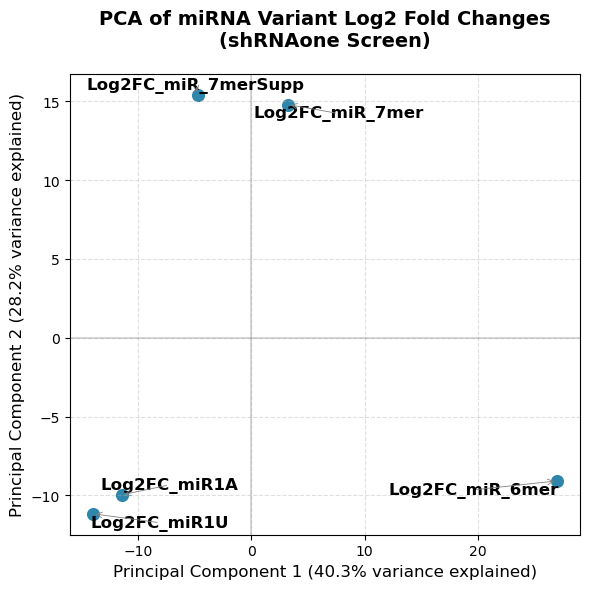

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ========================= LOAD DATA =========================
df = pd.read_excel("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/Log2FC_miR_shRNAone_byType.xlsx")

# ========================= PCA PREPARATION =========================
features = ["Log2FC_miR1U", "Log2FC_miR1A", "Log2FC_miR_7merSupp", 
            "Log2FC_miR_7mer", "Log2FC_miR_6mer"]

# Transpose so each miR variant is a "sample" (row)
data_for_pca = df[features].T

# Standardize
scaler = StandardScaler()
x_scaled = scaler.fit_transform(data_for_pca)

# Apply PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(x_scaled)

# Create PCA DataFrame with meaningful index (the miR variant names)
pca_df = pd.DataFrame(
    data=pca_features,
    columns=["PC1", "PC2"],
    index=data_for_pca.index   # ← This is the key fix: use actual column names
)

# ========================= PLOTTING =========================
plt.figure(figsize=(6, 6))

# Scatter plot
sns.scatterplot(
    x="PC1", 
    y="PC2", 
    data=pca_df, 
    s=120, 
    color="#2E86AB",
    edgecolor="white",
    linewidth=1.5
)

# Add text labels with adjust_text
texts = []
for i, row in pca_df.iterrows():
    t = plt.text(
        row["PC1"], 
        row["PC2"], 
        i,                                 # ← Now uses the real name (e.g. "Log2FC_miR1U")
        fontsize=12,
        weight="semibold",
        ha='center',
        va='center'
    )
    texts.append(t)

# Adjust text positions to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color="gray", lw=0.6),
    expand_points=(1.8, 1.8),
    force_points=(0.5, 0.5),
    force_text=(0.8, 0.8)
)

# Add explained variance to axes
var_ratio = pca.explained_variance_ratio_ * 100
plt.xlabel(f"Principal Component 1 ({var_ratio[0]:.1f}% variance explained)", fontsize=12)
plt.ylabel(f"Principal Component 2 ({var_ratio[1]:.1f}% variance explained)", fontsize=12)

plt.title("PCA of miRNA Variant Log2 Fold Changes\n(shRNAone Screen)", 
          fontsize=14, weight="bold", pad=20)

plt.grid(True, linestyle="--", alpha=0.4)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_figure/figures/preprocessing/PCA_miR_variants.pdf")
plt.show()



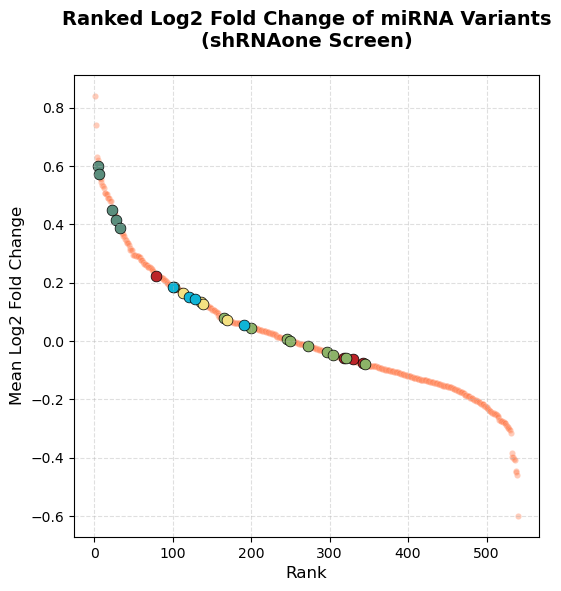

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd_log2FC = pd.read_excel("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/Log2FC_miR_shRNAone_byType.xlsx")
pd_log2FC = pd_log2FC[["miRNA", "Log2FC_miR1U", "Log2FC_miR1A"]]
pd_log2FC["Log2FC_mean"] = pd_log2FC[["Log2FC_miR1U", "Log2FC_miR1A"]].mean(axis=1)
pd_log2FC = pd_log2FC.sort_values(by="Log2FC_mean", ascending=False).copy()
pd_log2FC["Rank"] = range(1, len(pd_log2FC) + 1)
pd_log2FC

interested = [["Hsa-Mir-181-P1a_5p", "Hsa-Mir-181-P1c_5p", "Hsa-Mir-181-P2a_5p", "Hsa-Mir-181-P2c_5p"]]
interested.append(["Hsa-Let-7-P1b_5p", "Hsa-Let-7-P1c_5p", "Hsa-Let-7-P1d_5p", 
                   "Hsa-Let-7-P2a3_5p", "Hsa-Let-7-P2b2_5p", "Hsa-Let-7-P2b3_5p", 
                   "Hsa-Let-7-P2c1_5p", "Hsa-Let-7-P2c2_5p", "Hsa-Let-7-P2c3_5p"])
interested.append(["Hsa-Mir-30-P1a_5p", "Hsa-Mir-30-P1b_5p", "Hsa-Mir-30-P1d_5p", "Hsa-Mir-30-P2a_5p", "Hsa-Mir-30-P2b_5p"])
interested.append(["Hsa-Mir-430-P1_3p", "Hsa-Mir-430-P2_3p", "Hsa-Mir-430-P3_3p", "Hsa-Mir-430-P4_3p"])
interested.append(["Hsa-Mir-34-P1_5p", "Hsa-Mir-34-P2a_5p", "Hsa-Mir-34-P2b_5p", "Hsa-Mir-34-P3b_5p", "Hsa-Mir-34-P3a-v1_5p"])
interested_label = ["miR-181 family", "let-7 family", "miR-30 family", "miR-302 family", "miR-34 family"]
highlight_colors = ["#bc2429", "#8cb368", "#f4e182", "#0fb4d6", "#5b8e7d"]

plt.figure(figsize=(6, 6))
plt.scatter(
    pd_log2FC["Rank"], 
    pd_log2FC["Log2FC_mean"], 
    color="coral", 
    edgecolor="w",
    linewidth=0.2,
    s=20, 
    alpha=0.4
)

for idx in range(len(interested)):
    subset = pd_log2FC[pd_log2FC["miRNA"].isin(interested[idx])]
    plt.scatter(
        subset["Rank"], 
        subset["Log2FC_mean"], 
        color=highlight_colors[idx], 
        s=60, 
        edgecolor="black",
        linewidth=0.5,
        alpha=1,
        label=interested_label[idx]
    )
    # for _, row in subset.iterrows():
    #     plt.text(
    #         row["Rank"], 
    #         row["Log2FC_mean"], 
    #         row["miRNA"],
    #         fontsize=8, 
    #         weight="bold", 
    #         color=highlight_colors[idx],
    #         ha='right',
    #         va='bottom'
    #     )
plt.title("Ranked Log2 Fold Change of miRNA Variants\n(shRNAone Screen)", fontsize=14, weight="bold", pad=20)
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Mean Log2 Fold Change", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_figure/figures/preprocessing/ranked_Log2FC_miR_variants.pdf", bbox_inches="tight")
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("/home/wkkongaa/data/notebooks/250913_miR_screen_Sorafenib_resistance/DESeq2/results_sorafenib_vs_DMSO.csv")
df.rename(columns={df.columns[0]: 'shRNA'}, inplace=True)
interested = [["Hsa-Mir-181-P1a_5p", "Hsa-Mir-181-P1c_5p", "Hsa-Mir-181-P2a_5p", "Hsa-Mir-181-P2c_5p"]]
interested.append(["Hsa-Let-7-P1b_5p", "Hsa-Let-7-P1c_5p", "Hsa-Let-7-P1d_5p", 
                   "Hsa-Let-7-P2a3_5p", "Hsa-Let-7-P2b2_5p", "Hsa-Let-7-P2b3_5p", 
                   "Hsa-Let-7-P2c1_5p", "Hsa-Let-7-P2c2_5p", "Hsa-Let-7-P2c3_5p"])
interested.append(["Hsa-Mir-30-P1a_5p", "Hsa-Mir-30-P1b_5p", "Hsa-Mir-30-P1d_5p", "Hsa-Mir-30-P2a_5p", "Hsa-Mir-30-P2b_5p"])
interested.append(["Hsa-Mir-430-P1_3p", "Hsa-Mir-430-P2_3p", "Hsa-Mir-430-P3_3p", "Hsa-Mir-430-P4_3p"])
interested.append(["Hsa-Mir-34-P1_5p", "Hsa-Mir-34-P2a_5p", "Hsa-Mir-34-P2b_5p", "Hsa-Mir-34-P3b_5p", "Hsa-Mir-34-P3a-v1_5p"])
interested_label = ["miR-181 family", "let-7 family", "miR-30 family", "miR-302 family", "miR-34 family"]
log2FC = df["log2FoldChange"].tolist()
df_FL = pd.DataFrame({"shRNA": [name.split("_shRNAone_")[1] for name in df["shRNA"][:540]], \
                      "log2FoldChange_1U": log2FC[0:540],\
                      "log2FoldChange_1A": log2FC[540:1080]})

df_FL["log2FoldChange"] = (df_FL["log2FoldChange_1A"] + df_FL["log2FoldChange_1U"]) / 2
df_sorted = df_FL.sort_values(by="log2FoldChange", ascending=False)
df_sorted.to_excel("/home/wkkongaa/data/notebooks/250913_miR_screen_Sorafenib_resistance/figures/results_miR_Sorafenib_ranked_log2FC.xlsx", index=False)
log2FC = df_sorted["log2FoldChange"].tolist()
rank = [range(len(log2FC))]

name = df_sorted["shRNA"].tolist()
rank_interested = []
for family in interested:
    temp = []
    for miR in family:
        temp.append(name.index(miR))
    rank_interested.append(temp)
rank_interested

family_color = ['#D9D9D6', '#FF0000', '#FFA500', '#FFFF00', '#00FF00', '#00FFFF', '#0000FF', '#800080']
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(rank, log2FC, c="#000000", s=10)
log2FC_interested = []
for family in interested:
    temp = []
    for miR in family:
        temp.append(log2FC[name.index(miR)])
    log2FC_interested.append(temp)
for family in range(len(interested)):
    plt.scatter(rank_interested[family], log2FC_interested[family], c=family_color[family], label=interested_label[family], s=20, zorder=5)
ax.set_xlabel('Rank', fontsize=12)
# ax.set_xlim(-1, 110)
ax.set_ylabel('Log2FC', fontsize=12)
# ax.set_ylim(-0.5, 3.5)
ax.set_title("miR_Sorafenib_ranked_log2FC", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("figures/miR_Sorafenib_ranked_log2FC.pdf")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_preprocessing/Log2FC_miR_shRNAone_biological_replicates.csv") [["rep1_Log2FC", "rep2_Log2FC","rep3_Log2FC"]]

cols = df.columns.to_list()


['rep1_Log2FC', 'rep2_Log2FC', 'rep3_Log2FC']